# Greedy Layer-Wise Training of Deep Networks
**Authors:** Yoshua Bengio, Pascal Lamblin, Dan Popovici, Hugo Larochelle (Université de Montréal)

# https://proceedings.neurips.cc/paper_files/paper/2006/file/5da713a690c067105aeb2fae32403405-Paper.pdf

## Abstract
This paper empirically investigates why the greedy layer-wise unsupervised pre-training algorithm introduced by Hinton et al. (2006) for Deep Belief Networks (DBNs) is effective, and extends it in several directions. The authors argue that deep architectures can represent highly-varying functions far more compactly than shallow architectures, but that gradient-based optimization of deep networks from random initialization tends to get stuck in poor solutions. Through controlled experiments, the paper confirms the hypothesis that greedy layer-wise unsupervised pre-training primarily aids optimization by initializing weights near a good local minimum, yielding internal distributed representations that capture high-level abstractions and improve generalization. The authors also extend RBMs/DBNs to handle continuous-valued inputs, show that auto-encoders can substitute for RBMs as building blocks with comparable results, and propose a partially supervised variant to address cases where the input distribution is not informative enough about the supervised target.

## Problems
- Complexity theory suggests deep architectures can represent highly-varying functions exponentially more compactly than shallow architectures (e.g., kernel machines, single-hidden-layer neural networks), but until recently it was unclear how to effectively train such deep networks.
- Empirically, deep multi-layer neural networks were historically found to perform no better, and often worse, than shallow networks with one or two hidden layers, a negative result attributed to gradient-based optimization from random initialization getting stuck in poor local solutions.
- It remained unclear whether Hinton et al.'s greedy layer-wise unsupervised DBN pre-training algorithm succeeds primarily by solving an optimization problem, by acting as a regularizer, or through some other mechanism.
- The standard binary-unit RBM/DBN formulation handles continuous-valued inputs only through an ad hoc rescaling "trick" (treating pixel-intensity-like values as Bernoulli probabilities), which may be inappropriate for other types of continuous input variables (e.g., financial data).
- The greedy layer-wise unsupervised strategy is expected to fail when the input distribution $p(x)$ is not sufficiently informative about the conditional distribution of the supervised target $y$ given $x$ — a scenario the original DBN work did not address.

## Proposed Solutions
- Conduct controlled empirical comparisons between deep networks with and without greedy layer-wise pre-training, and between DBN (RBM-based) pre-training and an auto-encoder-based layer-wise pre-training variant, to isolate whether the strategy's benefit is primarily optimization-related or representation-related.
- Extend the RBM energy function to natively support continuous-valued visible units via two mechanisms:
  - **Linear energy units** (exponential or truncated exponential conditional densities) for input variables in $[0,\infty)$ or a bounded interval.
  - **Quadratic energy units** (Gaussian-distributed units), obtained by adding quadratic terms $\sum_i d_i^2 y_i^2$ to the energy function.
- Introduce and test an alternative **greedy layer-wise supervised** training procedure (training each new layer as the hidden layer of a one-hidden-layer supervised network, then discarding its output layer) to test whether the unsupervised nature of pre-training is essential.
- Propose a **partially supervised** layer-wise training criterion that adds gradient updates from a supervised prediction objective (using a temporary output layer) to the unsupervised reconstruction/contrastive divergence updates, applied primarily to the first layer, to address uncooperative input distributions.
- Propose training all DBN layers simultaneously (rather than strictly sequentially) as a practical variant, using a single global stopping criterion.

## Purpose
To empirically understand *why* greedy layer-wise unsupervised pre-training of deep networks works, specifically testing the hypothesis that it helps primarily by solving a difficult non-convex optimization problem (via better weight initialization near a good local minimum) rather than acting purely as a regularizer, and to extend the applicability of DBNs/RBMs to continuous-valued inputs and to supervised settings where the input distribution alone is not sufficiently predictive of the target.

## Methodology

### Deep Belief Networks and RBMs
The DBN models a joint distribution over input $x=\mathbf{g}^0$ and hidden layers $\mathbf{g}^1,\ldots,\mathbf{g}^\ell$:
$$P(x, \mathbf{g}^1, \mathbf{g}^2, \ldots, \mathbf{g}^\ell) = P(x|\mathbf{g}^1)P(\mathbf{g}^1|\mathbf{g}^2)\cdots P(\mathbf{g}^{\ell-2}|\mathbf{g}^{\ell-1})P(\mathbf{g}^{\ell-1},\mathbf{g}^\ell)$$
with factorized binary conditional layers:
$$P(\mathbf{g}^i_j=1|\mathbf{g}^{i+1}) = \text{sigm}\Big(b^i_j + \sum_k W^i_{kj}\mathbf{g}^{i+1}_k\Big) \quad (1)$$
The top-level prior $P(\mathbf{g}^{\ell-1},\mathbf{g}^\ell)$ is a Restricted Boltzmann Machine (RBM) with joint distribution $P(v,h) = \frac{1}{Z}e^{h'Wv+b'v+c'h}$ and energy function:
$$\text{energy}(v,h) = -h'Wv - b'v - c'h \quad (2)$$
RBM parameters $\theta=(W,b,c)$ are trained via **Contrastive Divergence** (typically $k=1$ Gibbs sampling step), approximating the log-likelihood gradient.

### Greedy Layer-Wise Unsupervised Pre-Training
Layers are trained one at a time: an RBM is trained on the empirical input distribution, its learned posterior $Q(\mathbf{g}^1|\mathbf{g}^0)$ is used to stochastically transform the data into samples for the next layer, and a new RBM is trained on this transformed empirical distribution $\hat{p}^1$. This process is justified by a variational bound showing that improving the upper-layer model can improve the bound on the training criterion of the layer below. After pre-training, the network can be **fine-tuned** by (a) generative fine-tuning (e.g., wake-sleep algorithm) or (b) discriminative fine-tuning via mean-field propagation $\mu^i=\text{sigm}(b^i+W^i\mu^{i-1})$ followed by gradient descent on a supervised criterion (squared error or cross-entropy), typically with a 20-fold larger learning rate than used for contrastive divergence.

### Continuous-Valued Extensions
- **Truncated exponential units:** for $y\in[0,1]$, conditional density $p(y|z) = \frac{\exp(ya(z))}{\int_0^1\exp(va(z))dv}$ where $a(z)=b+w'z$; conditional expectation $E[y|z] = \frac{1}{1-\exp(-a(z))} - \frac{1}{a(z)}$, exhibiting a sigmoidal-like non-linearity.
- **Gaussian units:** quadratic energy term added; conditional expectation $E[y|z] = \frac{a(z)}{2d^2}$ with inverse variance $d^2$; contrastive divergence gradient for $d$ is $2dy^2$.

### Alternative Layer-Wise Building Blocks and Strategies
- **Auto-encoder pre-training:** each layer trained to minimize reconstruction cross-entropy $R = -\sum_i x_i\log p_i(x) + (1-x_i)\log(1-p_i(x))$, with $p(x)=\text{sigm}(c+W\,\text{sigm}(b+W'x))$.
- **Greedy supervised pre-training:** each layer trained as the hidden layer of a one-hidden-layer supervised network, then its output layer discarded.
- **Partially supervised pre-training:** first-layer updates combine unsupervised (contrastive divergence/reconstruction) gradients with supervised prediction-error gradients via a temporary output layer.

### Experimental Setup
- **Experiment 1 (continuous inputs):** UCI Abalone dataset (2177 train / 1000 valid / 1000 test) and a financial "Cotton" futures dataset (13 continuous input features, averages of returns over windows up to 504 days; 3135 train / 1000 valid / 1000 test), comparing DBNs with binomial vs. Gaussian input units (two hidden layers, hyperparameters chosen via validation performance).
- **Experiment 2 (MNIST):** Five algorithms compared — (a) DBN (RBM pre-training), (b) deep net with auto-encoder pre-training, (c) deep net with greedy supervised pre-training, (d) deep net with no pre-training (random init), (e) shallow network (1 hidden layer, no pre-training). Architecture: 784 inputs, 10 outputs, 3 hidden layers (500–1000 units, selected via validation), fine-tuned via stochastic gradient descent on cross-entropy with a logistic regression output layer; L2 weight decay optimized.
- **Experiment 3:** Same as Experiment 2 but with the top hidden layer constrained to only 20 units, to test a specific hypothesis about why non-pre-trained networks achieve near-zero training error despite poor generalization.

## Results

### Continuous Inputs (Table 1)
| Model | Abalone train | Abalone valid | Abalone test | Cotton train | Cotton valid | Cotton test |
|---|---|---|---|---|---|---|
| Deep Network, no pre-training | 4.23 | 4.43 | 4.2 | 45.2% | 42.9% | 43.0% |
| Logistic regression | – | – | – | 44.0% | 42.6% | 45.0% |
| DBN, binomial inputs, unsupervised | 4.59 | 4.60 | 4.47 | 44.0% | 42.6% | 45.0% |
| DBN, binomial inputs, partially supervised | 4.39 | 4.45 | 4.28 | 43.3% | 41.1% | 43.7% |
| DBN, Gaussian inputs, unsupervised | 4.25 | 4.42 | 4.19 | 35.7% | 34.9% | 35.8% |
| DBN, Gaussian inputs, partially supervised | 4.23 | 4.43 | 4.18 | 27.5% | 28.4% | 31.4% |

- Gaussian input units substantially improved performance over binomial inputs on the Cotton dataset (e.g., unsupervised: 45.0% → 35.8% test error), consistent with the input variables being poorly suited to a binary/Bernoulli approximation.
- Partial supervision combined with Gaussian inputs achieved the best Cotton results (27.5% train / 28.4% valid / 31.4% test), substantially outperforming purely unsupervised pre-training, illustrating the value of the proposed fix for uncooperative input distributions.

### MNIST (Table 2, Experiments 2 and 3)
| Model | Exp.2 train | Exp.2 valid | Exp.2 test | Exp.3 train | Exp.3 valid | Exp.3 test |
|---|---|---|---|---|---|---|
| DBN, unsupervised pre-training | 0% | 1.2% | 1.2% | 0% | 1.5% | 1.5% |
| Deep net, auto-associator pre-training | 0% | 1.4% | 1.4% | 0% | 1.4% | 1.6% |
| Deep net, supervised pre-training | 0% | 1.7% | 2.0% | 0% | 1.8% | 1.9% |
| Deep net, no pre-training | .004% | 2.1% | 2.4% | .59% | 2.1% | 2.2% |
| Shallow net, no pre-training | .004% | 1.8% | 1.9% | 3.6% | 4.7% | 5.0% |

- In Experiment 2, all models achieved near-zero training error regardless of pre-training, yet unsupervised pre-trained models (DBN, auto-encoder) generalized substantially better (1.2–1.4% test error) than non-pre-trained deep or shallow networks (1.9–2.4% test error); differences greater than 0.1% were noted as statistically significant on MNIST.
- Auto-encoder-based pre-training performed comparably to RBM-based DBN pre-training (1.4% vs. 1.2% test error), indicating the specific generative building block is not critical to the strategy's success.
- Greedy **supervised** layer-wise pre-training underperformed both unsupervised variants (2.0% test error), suggesting supervised greediness may discard target-relevant information not recoverable by a single hidden layer.
- In Experiment 3 (top hidden layer constrained to 20 units), non-pre-trained deep networks' training error rose sharply (from ~0% to 0.59%) and generalization degraded further, with the authors also noting extremely high variance across runs without pre-training — directly supporting the optimization-based explanation, since forcing information through a narrow top layer exposes the poor internal representations learned without pre-training.
- Figure 1 (Cotton task) shows deep networks without pre-training plateauing at higher training classification error than DBN variants, visually illustrating the optimization difficulty of deep networks and the benefit of (partially) supervised pre-training.

## Conclusions
- The experiments support the central hypothesis that greedy layer-wise unsupervised pre-training primarily aids the optimization of deep networks by initializing weights in a region corresponding to good, high-level internal representations of the input, rather than acting merely as an implicit regularizer — evidenced most directly by the Experiment 3 finding that constraining representational capacity degrades even *training* error for non-pre-trained networks.
- This mechanism generalizes beyond the specific RBM/DBN framework: auto-encoders used as the greedy layer-wise building block achieve comparable generalization performance to RBM-based DBNs, indicating the benefit stems from the greedy, layer-wise, unsupervised training principle itself rather than any RBM-specific property.
- An unsupervised (rather than supervised) criterion at each layer is important: greedy layer-wise *supervised* pre-training underperforms unsupervised pre-training, plausibly because a supervised objective at an early layer may discard information about the target that could only be recovered through composition of multiple subsequent layers.
- Extending RBMs/DBNs with continuous-valued (truncated exponential or Gaussian) units yields substantial improvements over the standard binary-unit approximation when input variables are genuinely continuous and poorly suited to a Bernoulli-probability interpretation, as demonstrated on the financial Cotton dataset.
- When the input distribution $p(x)$ is not sufficiently informative about the supervised target $y$ (an "uncooperative" input distribution), purely unsupervised greedy pre-training is inadequate; a simple partially supervised variant — injecting supervised gradient information into the first layer's training — substantially improves results in this regime.
- The paper's findings collectively establish greedy layer-wise pre-training as a general, robust principle for training deep architectures (applicable to both RBM- and auto-encoder-based layers, and extendable to continuous and partially-supervised settings), addressing the previously poorly understood optimization difficulty of deep networks and enabling the representational efficiency advantages of depth to be realized in practice.

# Mathematical and Statistical Content Summary

## 1. Complexity Bounds for Representing Functions (Motivating Theory)
$$O(2^d) \text{ (Gaussian SVM)}, \quad O(d^2) \text{ (one-hidden-layer NN)}, \quad O(d) \text{ (multi-layer, } O(\log_2 d)\text{ layers)}, \quad O(1) \text{ (recurrent NN)}$$

**Explanation:** These are parameter/example counts needed to represent the $d$-input parity function under different architectures. They illustrate, via a concrete example, that shallow architectures can require **exponentially** more computational elements than deep ones to represent the same function — the core theoretical motivation for studying deep networks at all.

## 2. Local Kernel Behavior
$$K(x,y) \to \text{constant as } \|x-y\| \to \infty$$

**Explanation:** Describes the property of "local" kernels (e.g., Gaussian/RBF kernel) used in kernel machines like SVMs: similarity collapses to a constant for distant points. This underlies the paper's argument that local, non-parametric methods generalize poorly on "highly-varying" functions, motivating non-local, compositional (deep) alternatives.

## 3. Boolean Circuit Complexity Bound
$$O(\log d) \text{ layers with } O(d) \text{ elements each (deep)} \quad \text{vs.} \quad O(2^d) \text{ elements (2 layers, shallow)}$$

**Explanation:** A further complexity-theoretic example (e.g., binary multiplication circuits) showing that restricting circuit depth to 2 layers can force an exponential blow-up in the number of elements needed, reinforcing the paper's structural argument for depth.

## 4. Deep Belief Network Joint Distribution
$$P(x, \mathbf{g}^1, \mathbf{g}^2, \ldots, \mathbf{g}^\ell) = P(x|\mathbf{g}^1)P(\mathbf{g}^1|\mathbf{g}^2)\cdots P(\mathbf{g}^{\ell-2}|\mathbf{g}^{\ell-1})P(\mathbf{g}^{\ell-1}, \mathbf{g}^\ell)$$

**Explanation:** Defines the DBN as a layered generative model: the joint probability of the input and all hidden layers factors into a chain of conditional distributions between successive layers, with the top two layers jointly modeled. This is the central probabilistic object the paper's entire training strategy is built to approximate and optimize.

## 5. Layer-to-Layer Conditional (Sigmoid Belief Layer)
$$P(\mathbf{g}^i|\mathbf{g}^{i+1}) = \prod_{j=1}^{n^i} P(\mathbf{g}^i_j|\mathbf{g}^{i+1}), \quad P(\mathbf{g}^i_j=1|\mathbf{g}^{i+1}) = \text{sigm}\Big(b^i_j + \sum_{k=1}^{n^{i+1}} W^i_{kj}\mathbf{g}^{i+1}_k\Big) \quad (1)$$
with $\text{sigm}(t) = 1/(1+e^{-t})$

**Explanation:** Each hidden layer's units are conditionally independent given the layer above, with each unit's probability of being "on" (=1) given by a logistic sigmoid of a weighted sum of the layer above — the standard binary stochastic neuron. This factorized form is what makes probability computation and sampling tractable layer-by-layer, and it's used both for hidden layers and (with $\mathbf{g}^0=x$) for the visible/input layer.

## 6. RBM Joint Distribution (Boltzmann Form)
$$P(v,h) = \frac{1}{Z}e^{h'Wv + b'v + c'h}$$

**Explanation:** The top-level prior of a DBN is a Restricted Boltzmann Machine, an undirected graphical model over visible units $v$ and hidden units $h$, expressed via the exponential of a bilinear energy term. $Z$ is the normalizing partition function (sum over all $v,h$ configurations), generally intractable to compute exactly — motivating the sampling-based training approach described below.

## 7. RBM Energy Function
$$\text{energy}(v,h) = -h'Wv - b'v - c'h \quad (2)$$

**Explanation:** The negative exponent argument in the Boltzmann distribution; configurations with lower energy are more probable. $W$ is the weight matrix coupling visible and hidden units, $b,c$ are bias vectors. This function is the object whose derivative with respect to parameters drives all RBM learning updates.

## 8. RBM Conditional Distributions (Bipartite Independence)
$$P(v_k=1|h) = \text{sigm}\Big(b_k + \sum_j W_{jk}h_j\Big), \qquad Q(h_j=1|v) = \text{sigm}\Big(c_j + \sum_k W_{jk}v_k\Big)$$

**Explanation:** Because the RBM's bipartite structure (no within-layer connections) makes $v$ conditionally independent given $h$ and vice versa, both conditionals factorize into independent sigmoid units. This is what makes alternating (Gibbs) sampling between $v$ and $h$ simple and efficient — the computational backbone of RBM training.

## 9. Log-Likelihood of an RBM
$$\log P(v_0) = \log\sum_h e^{-\text{energy}(v_0,h)} - \log\sum_{v,h} e^{-\text{energy}(v,h)}$$

**Explanation:** Expresses the log-probability of an observed data point $v_0$ as a difference between a "data-dependent" term (summing over hidden configurations only) and a "model" term (summing over all configurations) — the second term is the log-partition function, generally intractable for realistic model sizes.

## 10. Gradient of RBM Log-Likelihood
$$\frac{\partial \log P(v_0)}{\partial\theta} = -\sum_{h_0} Q(h_0|v_0)\frac{\partial\,\text{energy}(v_0,h_0)}{\partial\theta} + \sum_{v_k,h_k} P(v_k,h_k)\frac{\partial\,\text{energy}(v_k,h_k)}{\partial\theta}$$

**Explanation:** The exact gradient decomposes into a "positive phase" term (expectation under the data-conditioned hidden posterior) minus a "negative phase" term (expectation under the full model distribution, obtained as $k\to\infty$ in a Gibbs chain). This is the theoretical target that Contrastive Divergence (below) approximates, since the negative-phase expectation is intractable to compute exactly.

## 11. Unbiased Stochastic Gradient Estimator
$$-\frac{\partial\,\text{energy}(v_0,h_0)}{\partial\theta} + E_{h_k}\Big[\frac{\partial\,\text{energy}(v_k,h_k)}{\partial\theta}\Big| v_k\Big]$$

**Explanation:** A Monte Carlo estimate of the log-likelihood gradient using one sample $h_0$ from the data-conditioned posterior and one sample $(v_k,h_k)$ from a long-run Gibbs chain; the inner expectation over $h_k$ given $v_k$ is computed exactly (tractable due to conditional factorization). This is a **statistical estimator** — it is unbiased but requires the chain to reach equilibrium ($k\to\infty$), which is computationally impractical, motivating Contrastive Divergence.

## 12. Contrastive Divergence (CD-k) Approximation
**Explanation:** Instead of running the Gibbs chain to convergence ($k\to\infty$), Contrastive Divergence truncates it to a small number of steps (typically $k=1$), starting the chain at the observed data $v_0=x$. This introduces bias but is empirically effective and vastly cheaper computationally. It is the actual training algorithm used for every RBM in the paper's experiments, and the stopping criterion proxy used is the reconstruction error $-\log P(v_1=x|v_0=x)$.

## 13. Greedy Layer-Wise Empirical Distribution Propagation
$$\hat{p}^1(\mathbf{g}^1) = \sum_{\mathbf{g}^0} \hat{p}(\mathbf{g}^0)\,Q(\mathbf{g}^1|\mathbf{g}^0)$$
$$\hat{p}^\ell(\mathbf{g}^\ell) = \sum_{\mathbf{g}^{\ell-1}} \hat{p}^{\ell-1}(\mathbf{g}^{\ell-1})\,Q(\mathbf{g}^\ell|\mathbf{g}^{\ell-1})$$

**Explanation:** Defines how the empirical data distribution is stochastically "pushed up" through the network: after training layer $\ell{-}1$'s RBM, its learned posterior $Q(\mathbf{g}^\ell|\mathbf{g}^{\ell-1})$ transforms samples from the empirical distribution at layer $\ell{-}1$ into an implicit empirical distribution at layer $\ell$, which becomes the training data for the next RBM. Though this distribution can't be written down explicitly, it's easy to **sample** from it — simply propagate a training example stochastically through each learned $Q$ in turn. This is the mathematical core of the greedy layer-wise algorithm.

## 14. Variational Bound Justification for Greedy Stacking
**Explanation:** The paper states (citing Hinton et al. 2006) that under appropriate initialization and sufficient hidden units, improvements in the training criterion for a newly added layer (fitting $\hat{p}^\ell$) are guaranteed to translate into improvements in the training criterion (likelihood) of the layer below (with respect to $\hat{p}^{\ell-1}$). This is a **variational lower bound** argument: rather than directly maximizing an intractable joint likelihood, the greedy procedure is justified because each layer's local optimization provably does not harm (and typically improves) a bound on the global objective.

## 15. Mean-Field Propagation (Deterministic Approximation)
$$\mu^i = \text{sigm}(b^i + W^i\mu^{i-1})$$

**Explanation:** Rather than propagating *stochastic* binary samples through the network (as in training), mean-field propagation replaces each layer's random binary values with their expected value (probability), yielding a deterministic function of the input. This gives a fast, deterministic way to compute internal representations $P(\mathbf{g}^i|x)$ for all layers given an input, used both for approximating posteriors and for supervised fine-tuning via standard backpropagation-style gradient descent.

## 16. Truncated/Standard Exponential Conditional Density (Continuous Units)
$$a(z) = b + w'z, \qquad p(y|z) = \frac{\exp(ya(z))\mathbb{1}_{y\in I}}{\int_v \exp(va(z))\mathbb{1}_{v\in I}\,dv}$$

**Explanation:** Generalizes the RBM unit's conditional distribution from binary to continuous by keeping the same *linear* energy term $ya(z)$ but allowing $y$ to range over an interval $I$ rather than $\{0,1\}$. For $I=[0,\infty)$, this yields a standard exponential distribution (requiring $a(z)<0$ everywhere for normalizability); its mean is $-1/a(z)$.

## 17. Truncated Exponential on $[0,1]$
$$\text{Normalizing integral} = \frac{\exp(-a(z))-1}{a(z)}, \qquad E[y|z] = \frac{1}{1-\exp(-a(z))} - \frac{1}{a(z)}$$

**Explanation:** Restricting $y$ to the closed interval $[0,1]$ (appropriate for many real applications) yields a *truncated* exponential density whose normalizing constant always exists. Its conditional expectation has a **sigmoidal, saturating, monotone non-linearity** in $a(z)$ — notably, unlike the linear (unbounded) exponential or Gaussian cases, this preserves a useful non-linear transformation, which matters if such units are used as hidden (not just visible) units.

## 18. Inverse-CDF Sampling for Truncated Exponential
$$F^{-1}(U) = \frac{\log\big(1 - U\times(1-\exp(a(z)))\big)}{a(z)}$$

**Explanation:** A standard statistical technique (inverse transform sampling) for drawing a sample $y$ from the truncated exponential conditional density given a uniform random sample $U\sim\text{Unif}(0,1)$. This is what makes the truncated-exponential unit practically usable inside a Gibbs-sampling-based Contrastive Divergence training loop.

## 19. Gaussian (Quadratic Energy) Units
$$\text{Added energy term: } \sum_i d_i^2 y_i^2, \qquad E[y|z] = \frac{a(z)}{2d^2}$$

**Explanation:** Adding a quadratic term to the energy function (rather than only linear terms) makes the conditional distribution of $y$ Gaussian, with $d^2$ acting as the (unconditional) inverse variance and the conditional mean depending linearly on the inputs $z$ through $a(z)$. This gives a principled way to model genuinely continuous, real-valued (not merely bounded) inputs such as financial return averages.

## 20. Contrastive Divergence Gradient for Quadratic Parameter
$$\frac{\partial\,\text{energy}}{\partial d} = 2dy^2$$

**Explanation:** The derivative of the added quadratic energy term with respect to the inverse-variance parameter $d$, needed to compute the Contrastive Divergence weight update for Gaussian units — showing that even with the added quadratic term, gradients remain simple closed-form expressions of the unit's value, consistent in spirit with the linear-unit case (input × output).

## 21. Auto-Encoder Reconstruction Function
$$p(x) = \text{sigm}\big(c + W\,\text{sigm}(b+W'x)\big)$$

**Explanation:** Defines a single auto-encoder layer: input $x$ is encoded via $\text{sigm}(b+W'x)$ and decoded back via a second sigmoid layer using the *transposed* weight matrix $W'$ (tied weights), producing a vector of reconstruction probabilities $p(x)$ for each input bit. This is the deterministic feedforward alternative to the RBM as a layer-wise building block.

## 22. Reconstruction Cross-Entropy (Auto-Encoder Training Criterion)
$$R = -\sum_i x_i\log p_i(x) + (1-x_i)\log(1-p_i(x))$$

**Explanation:** The auto-encoder's training loss: the binary cross-entropy between the true input bits (or bit probabilities) $x_i$ and the reconstructed probabilities $p_i(x)$. Minimizing $R$ via gradient descent is the auto-encoder analogue of maximizing RBM log-likelihood via Contrastive Divergence, and the paper shows both criteria produce comparable downstream generalization when used for greedy layer-wise pre-training.

## 23. Statistical Significance Threshold (MNIST Experiments)
**Explanation:** The paper states that on the MNIST test set, differences in classification error greater than 0.1% are considered statistically significant. This is a practical significance criterion (given the fixed, large MNIST test set size) used to interpret the comparative results in Table 2 — e.g., distinguishing a genuinely better-performing pre-training strategy from noise.

## 24. Mean Squared Error and Classification Error (Evaluation Metrics)
**Explanation:** Two standard statistical evaluation metrics used across experiments: mean squared prediction error (Abalone regression task, Table 1) and classification error rate (Cotton binary task, MNIST digit classification, Tables 1–2), each computed separately on training, validation, and test sets. Validation-set error is used throughout for model/hyperparameter selection (number of hidden units, layer sizes, learning rates, L2 weight decay), a standard statistical model-selection procedure to avoid overfitting-driven comparisons.

## 25. L2 Weight Decay Regularization
**Explanation:** An L2 penalty on the weights (referenced as an optimized hyperparameter in the MNIST experiments) added to the training objective to constrain weight magnitude. The paper notes this, combined with stochastic gradient descent, may explain why auto-encoders with non-decreasing layer sizes do not degenerate into learning the trivial identity mapping despite having sufficient capacity to do so.

## Summary Table of Key Mathematical/Statistical Elements

| Concept | Type | Role in Paper |
|---|---|---|
| Parity/circuit complexity bounds | Complexity theory | Motivates depth over shallow architectures |
| DBN joint distribution factorization | Probabilistic graphical model | Defines the generative target model |
| Sigmoid belief layer (Eq. 1) | Conditional probability model | Layer-to-layer generative mechanism |
| RBM joint/energy (Eqs. 2) | Undirected graphical model | Top-level building block of a DBN |
| RBM log-likelihood gradient | Exact gradient decomposition | Theoretical training target |
| Contrastive Divergence | Approximate stochastic learning algorithm | Practical RBM training method used throughout |
| Greedy empirical distribution propagation | Recursive sampling procedure | Core mechanism of layer-wise pre-training |
| Variational bound | Theoretical justification | Justifies greedy stacking of layers |
| Mean-field propagation | Deterministic approximation | Fast posterior/representation computation, fine-tuning |
| Truncated exponential units | Continuous probability distribution | Extends RBMs to bounded continuous inputs |
| Gaussian (quadratic energy) units | Continuous probability distribution | Extends RBMs to unbounded continuous inputs |
| Inverse-CDF sampling | Statistical sampling technique | Enables Gibbs sampling with continuous units |
| Auto-encoder reconstruction + cross-entropy | Deterministic model + loss function | Alternative unsupervised layer-wise building block |
| Classification/MSE error, significance threshold | Evaluation statistics | Comparative performance assessment |
| L2 weight decay | Regularization | Prevents degenerate/trivial solutions |

## Overall Role of the Mathematics in the Paper
The mathematics serves three interlocking purposes: (1) **motivating** depth via complexity-theoretic bounds showing shallow architectures can require exponentially more resources than deep ones; (2) **defining and training** the core probabilistic model (DBN/RBM) via its joint distribution, energy function, exact log-likelihood gradient, and the Contrastive Divergence approximation that makes training tractable; and (3) **extending and validating** this framework — via continuous-unit energy functions (truncated exponential, Gaussian), an auto-encoder alternative building block, mean-field deterministic propagation for fine-tuning, and standard statistical evaluation/regularization practices — to support the paper's central empirical claim that greedy layer-wise pre-training succeeds primarily by improving optimization of deep networks.

# Structured Review Table: Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Complexity-theoretic analyses show shallow architectures (kernel machines, single-hidden-layer neural networks) can require exponentially more computational elements or examples than deep architectures to represent highly-varying functions (e.g., the parity function). | Local kernel methods and shallow networks are fundamentally inefficient for representing complex, highly-varying functions needed for AI tasks (vision, language, speech), requiring impractically large numbers of examples/parameters. | Studies and validates greedy layer-wise training of Deep Belief Networks (DBNs), which use composed non-linearities across multiple layers to represent such functions compactly, motivated directly by these complexity bounds. |
| 2 | Empirically, deep multi-layer neural networks trained from random initialization via standard gradient-based optimization were historically found to perform no better, and often worse, than shallow (one/two hidden layer) networks. | This negative empirical result discouraged the use of deep architectures in practice despite their theoretical representational advantages, and the underlying cause (optimization difficulty vs. other factors) was not well understood or reported in the literature. | Proposes and empirically tests the hypothesis that gradient-based optimization of deep networks from random initialization gets stuck in poor local solutions, and evaluates greedy layer-wise unsupervised pre-training (Hinton et al.'s DBN algorithm) as a remedy that better initializes weights. |
| 3 | It was unclear whether the success of Hinton et al.'s greedy layer-wise DBN pre-training algorithm stemmed primarily from solving a difficult optimization problem, from a regularization effect, or from some other mechanism — this strategy "has not yet been much exploited in machine learning" and lacked empirical dissection. | Without understanding the underlying mechanism, it is difficult to determine when and why the strategy should be expected to work, or how to extend/adapt it to new settings. | Designs controlled experiments (Experiments 2 and 3 on MNIST) — including constraining the top hidden layer to 20 units — that isolate and support the hypothesis that pre-training mainly aids optimization by initializing hidden layers with more meaningful, high-level representations of the input. |
| 4 | The standard binary-unit RBM/DBN formulation handles continuous-valued inputs only by an ad hoc rescaling "trick" (treating scaled continuous values as Bernoulli probabilities), which works for pixel gray levels but may be inappropriate for other continuous input types (e.g., financial returns). | This limits the applicability of RBMs/DBNs to domains with genuinely continuous, potentially unbounded or non-probability-like input variables, where the binary approximation could degrade model quality. | Extends the RBM energy function to natively support continuous-valued visible units via linear-energy (exponential/truncated exponential) and quadratic-energy (Gaussian) unit formulations, with corresponding tractable Contrastive Divergence updates and sampling procedures. |
| 5 | It was unclear whether the RBM specifically (as opposed to the general greedy, layer-wise, unsupervised principle) is essential to the pre-training strategy's success, since RBMs have specific generative/undirected-model properties. | If the benefit were RBM-specific, the strategy's applicability would be limited to models compatible with Contrastive Divergence training, restricting broader adoption of the layer-wise pre-training principle. | Tests auto-encoders as an alternative layer-wise building block (trained via reconstruction cross-entropy instead of Contrastive Divergence) and shows they yield comparable generalization performance to RBM-based DBNs on MNIST, supporting a more general greedy-layer-wise principle. |
| 6 | It was unclear whether the *unsupervised* nature of each layer's training objective is necessary, or whether a purely supervised, greedy, layer-wise procedure would work equally well. | Without this comparison, practitioners could not determine whether unsupervised pre-training is a critical ingredient or merely one viable option among equally effective greedy strategies. | Introduces and tests a greedy layer-wise *supervised* pre-training variant (each layer trained as the hidden layer of a one-hidden-layer supervised network) and shows it underperforms unsupervised pre-training, indicating the unsupervised objective is important, likely because a purely supervised greedy criterion may discard target-relevant information recoverable only through deeper composition. |
| 7 | In initial MNIST experiments, all models — including those without any pre-training — achieved near-zero training error, which superficially appears to contradict the hypothesis that pre-training mainly solves an optimization problem (since poor optimization would typically be expected to produce poor training error, not just poor test error). | This apparent contradiction, if unresolved, would undermine confidence in the optimization-based explanation for why greedy layer-wise pre-training improves generalization. | Proposes and empirically confirms (Experiment 3) the hypothesis that, without pre-training, the top two layers can still fit the training set almost perfectly by acting as a shallow "fat" network on top of a poorly initialized lower representation; constraining the top hidden layer to only 20 units causes training error to degrade significantly without pre-training, and reveals extremely high variance across runs, directly supporting the optimization-difficulty explanation. |
| 8 | The greedy layer-wise unsupervised pre-training strategy is expected to fail when the input distribution $p(x)$ is not sufficiently informative about the conditional distribution of the supervised target $y$ given $x$ (an "uncooperative" input distribution) — a scenario particularly relevant to regression problems and not addressed in the original DBN formulation. | In such settings, purely unsupervised pre-training cannot be expected to discover representations useful for the supervised task, since the pre-training objective (modeling $p(x)$) is decoupled from the true objective of interest (predicting $y$ from $x$). | Proposes a partially supervised layer-wise training criterion that combines unsupervised (Contrastive Divergence or reconstruction) weight updates with supervised prediction-error gradient updates (via a temporary output layer), applied primarily to the first layer, and demonstrates substantial performance improvements on a financial (Cotton futures) prediction task using this approach. |
| 9 | The standard layer-wise DBN training procedure requires explicitly deciding, in advance, the number of training iterations to allocate to each layer before moving to the next, which is an additional hyperparameter-tuning burden. | This sequential, per-layer stopping-criterion requirement complicates training, particularly for very large or streaming/online datasets where cycling back over training data is impractical. | Proposes and tests a variant in which all layers are trained simultaneously (each still greedily modeling its own input, ignoring higher layers), enabling a single global stopping criterion; experiments show this variant performs at least as well as the original sequential algorithm, at a modest increase in computation time. |

In [1]:
# ============================================================================
# Educational Replication: "Greedy Layer-Wise Training of Deep Networks"
# (Bengio, Lamblin, Popovici & Larochelle, 2007, NeurIPS)
#
# This paper studies IMAGE classification with deep networks (MNIST in the
# original paper), and proposes GREEDY LAYER-WISE UNSUPERVISED PRE-TRAINING
# (using RBMs or, equivalently per the paper, AUTO-ENCODERS) followed by
# SUPERVISED FINE-TUNING, to overcome the optimization difficulty of
# training deep networks from random initialization. CIFAR-10 is an
# appropriate substitute image dataset for this paper (unlike prior NLP
# papers in this series). We replicate the paper's AUTO-ENCODER-based
# greedy layer-wise pre-training variant (Section 4), since it is simpler
# to implement in PyTorch than RBM + Contrastive Divergence while the paper
# itself shows it yields comparable results to RBM-based DBN pre-training.
#
# Single-cell, educational PyTorch implementation.
# Do NOT execute automatically -- for manual run in Colab/Jupyter.
# ============================================================================

import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image as IPImage

In [2]:
# ----------------------------------------------------------------------------
# 0. GLOBAL WHITE-THEME SETTINGS (applied everywhere, per instructions)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "grid.color": "lightgrey",
    "legend.labelcolor": "black",
    "savefig.facecolor": "white",
})

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

In [ ]:
# ----------------------------------------------------------------------------
# 1. DATASET PREPARATION (HuggingFace CIFAR-10, mandatory)
# ----------------------------------------------------------------------------

ds = load_dataset("uoft-cs/cifar10")

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class HFCIFAR10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = sample["label"]
        return img_tensor, label

train_dataset_full = HFCIFAR10Dataset(ds["train"], train_transform)
test_dataset_full = HFCIFAR10Dataset(ds["test"], test_transform)

train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Sanity check
sample_imgs, sample_labels = next(iter(train_loader))
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Shape of one batch of images: {sample_imgs.shape}")
print(f"Label range: {sample_labels.min().item()} to {sample_labels.max().item()}")
print(f"First 8 class names in batch: {[CLASS_NAMES[l] for l in sample_labels[:8].tolist()]}")

In [4]:
# ----------------------------------------------------------------------------
# 2. MODEL DEFINITION
#
# Following the paper's architecture style: a deep MLP with 3 hidden layers
# (Section "Experiment 2": 784 inputs, 3 hidden layers, logistic regression
# output). Here inputs are flattened 64x64x3 images. Layer sizes are kept
# small for an educational demo. Each hidden layer is first pre-trained
# GREEDILY as an AUTO-ENCODER (Section 4, "Training each layer as an
# auto-encoder"): reconstruction criterion R = -sum[x*log(p(x)) +
# (1-x)*log(1-p(x))], using tied weights p(x)=sigm(c+W*sigm(b+W'x)).
# After all layers are pre-trained, a classifier head is added and the
# WHOLE network is fine-tuned end-to-end with a supervised criterion
# (cross-entropy), exactly as described in Section 2.4 "Supervised
# fine-tuning".
# ----------------------------------------------------------------------------

INPUT_DIM = 3 * 64 * 64
HIDDEN_DIMS = [256, 128, 64]  # 3 hidden layers, as in the paper's MNIST setup
NUM_CLASSES = 10

class AutoEncoderLayer(nn.Module):
    """
    Single greedy layer-wise auto-encoder building block (paper Section 4).
    p(x) = sigm(c + W * sigm(b + W' * x))  -- tied weights (encoder = decoder^T)
    """
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.W = nn.Parameter(torch.randn(hidden_dim, in_dim) * 0.01)  # encoder/decoder shared weight
        self.b = nn.Parameter(torch.zeros(hidden_dim))                 # hidden bias
        self.c = nn.Parameter(torch.zeros(in_dim))                     # visible/reconstruction bias

    def encode(self, x):
        return torch.sigmoid(x @ self.W.t() + self.b)  # sigm(b + W'x)

    def decode(self, h):
        return torch.sigmoid(h @ self.W + self.c)       # sigm(c + W*h)

    def forward(self, x):
        h = self.encode(x)
        x_recon = self.decode(h)
        return h, x_recon


class DeepGreedyNet(nn.Module):
    """
    Full deep network assembled from greedily pre-trained auto-encoder
    layers, with a final logistic-regression (linear+softmax) classifier
    head added on top for supervised fine-tuning, per Section 2.4 of the
    paper.
    """
    def __init__(self, input_dim, hidden_dims, num_classes):
        super().__init__()
        self.ae_layers = nn.ModuleList()
        prev_dim = input_dim
        for h_dim in hidden_dims:
            self.ae_layers.append(AutoEncoderLayer(prev_dim, h_dim))
            prev_dim = h_dim
        self.classifier = nn.Linear(prev_dim, num_classes)  # logistic regression head

    def forward(self, x):
        h = x
        for layer in self.ae_layers:
            h = layer.encode(h)
        logits = self.classifier(h)
        return logits

model = DeepGreedyNet(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 3200458


In [5]:
# ----------------------------------------------------------------------------
# 3. GREEDY LAYER-WISE UNSUPERVISED PRE-TRAINING
#
# Trains each auto-encoder layer IN SEQUENCE, on the (frozen) representation
# produced by all previously trained layers -- exactly the greedy layer-wise
# procedure described in the paper (Section 2.3 / Section 4), using
# reconstruction cross-entropy as the per-layer training criterion.
# ----------------------------------------------------------------------------

def flatten_batch(imgs):
    # Normalize to roughly (0,1) range for Bernoulli-style auto-encoder targets,
    # matching the paper's requirement that x_i in (0,1) for the reconstruction
    # cross-entropy criterion.
    x = imgs.view(imgs.size(0), -1)
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x

NUM_PRETRAIN_EPOCHS = 3  # kept small: pre-training is a distinct paper-specific phase

pretrain_loss_history = {i: [] for i in range(len(HIDDEN_DIMS))}  # per-layer reconstruction loss

print("\n--- Greedy Layer-Wise Unsupervised Pre-Training (auto-encoders) ---")
for layer_idx, ae_layer in enumerate(model.ae_layers):
    optimizer_ae = optim.Adam(ae_layer.parameters(), lr=0.01)
    for epoch in range(NUM_PRETRAIN_EPOCHS):
        running_loss, running_count = 0.0, 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            x = flatten_batch(imgs)
            # Propagate through all PREVIOUSLY pre-trained (frozen) layers first
            with torch.no_grad():
                for prev_idx in range(layer_idx):
                    x = model.ae_layers[prev_idx].encode(x)

            optimizer_ae.zero_grad()
            h, x_recon = ae_layer(x)
            # Reconstruction cross-entropy: R = -sum[x*log(p) + (1-x)*log(1-p)]
            eps = 1e-7
            recon_loss = -(x * torch.log(x_recon + eps) + (1 - x) * torch.log(1 - x_recon + eps)).sum(dim=1).mean()
            recon_loss.backward()
            optimizer_ae.step()

            running_loss += recon_loss.item() * x.size(0)
            running_count += x.size(0)

        epoch_loss = running_loss / running_count
        pretrain_loss_history[layer_idx].append(epoch_loss)
        print(f"  Layer {layer_idx+1}/{len(HIDDEN_DIMS)} | Epoch {epoch+1}/{NUM_PRETRAIN_EPOCHS} | "
              f"Reconstruction Loss: {epoch_loss:.4f}")


--- Greedy Layer-Wise Unsupervised Pre-Training (auto-encoders) ---
  Layer 1/3 | Epoch 1/3 | Reconstruction Loss: 8450.5871
  Layer 1/3 | Epoch 2/3 | Reconstruction Loss: 8387.9348
  Layer 1/3 | Epoch 3/3 | Reconstruction Loss: 8367.2753
  Layer 2/3 | Epoch 1/3 | Reconstruction Loss: 15.4767
  Layer 2/3 | Epoch 2/3 | Reconstruction Loss: 1.3837
  Layer 2/3 | Epoch 3/3 | Reconstruction Loss: 1.3041
  Layer 3/3 | Epoch 1/3 | Reconstruction Loss: 88.3298
  Layer 3/3 | Epoch 2/3 | Reconstruction Loss: 88.1745
  Layer 3/3 | Epoch 3/3 | Reconstruction Loss: 88.1741


In [6]:
# ----------------------------------------------------------------------------
# 4. SUPERVISED FINE-TUNING (5 epochs only)
#
# Adds a logistic regression layer on top and fine-tunes the WHOLE network
# via stochastic gradient descent on cross-entropy, per Section 2.4.
# ----------------------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # smaller LR for fine-tuning stability

NUM_EPOCHS = 5

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "per_class_acc_by_epoch": []
}

def evaluate(loader):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_preds, all_labels, all_confidences = [], [], []
    class_correct = [0] * NUM_CLASSES
    class_total = [0] * NUM_CLASSES
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            x = imgs.view(imgs.size(0), -1)
            x = (x - x.min()) / (x.max() - x.min() + 1e-8)
            logits = model(x)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            confs = probs.max(dim=1).values

            total_loss += loss.item() * imgs.size(0)
            total_correct += (preds == labels).sum().item()
            total_count += imgs.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_confidences.extend(confs.cpu().tolist())

            for c in range(NUM_CLASSES):
                mask = (labels == c)
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    per_class_acc = [
        (class_correct[c] / class_total[c] if class_total[c] > 0 else 0.0)
        for c in range(NUM_CLASSES)
    ]
    return avg_loss, avg_acc, per_class_acc, all_preds, all_labels, all_confidences


print("\n--- Supervised Fine-Tuning (whole network) ---")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, running_correct, running_count = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        x = imgs.view(imgs.size(0), -1)
        x = (x - x.min()) / (x.max() - x.min() + 1e-8)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_count += imgs.size(0)

    train_loss = running_loss / running_count
    train_acc = running_correct / running_count

    val_loss, val_acc, per_class_acc, val_preds, val_labels, val_confs = evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["per_class_acc_by_epoch"].append(per_class_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")


--- Supervised Fine-Tuning (whole network) ---
Epoch 1/5 | train_loss=2.3094 train_acc=0.1005 | val_loss=2.3016 val_acc=0.1825
Epoch 2/5 | train_loss=2.3041 train_acc=0.1050 | val_loss=2.3023 val_acc=0.1175
Epoch 3/5 | train_loss=2.3055 train_acc=0.1060 | val_loss=2.3012 val_acc=0.1175
Epoch 4/5 | train_loss=2.3008 train_acc=0.1135 | val_loss=2.3044 val_acc=0.1050
Epoch 5/5 | train_loss=2.3016 train_acc=0.1115 | val_loss=2.2971 val_acc=0.1175


In [7]:
# ----------------------------------------------------------------------------
# 5. PREDICTION PIPELINE (sample predictions)
# ----------------------------------------------------------------------------

model.eval()
sample_imgs, sample_labels = next(iter(test_loader))
sample_imgs, sample_labels = sample_imgs.to(device), sample_labels.to(device)
with torch.no_grad():
    x = sample_imgs.view(sample_imgs.size(0), -1)
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)
    confs = probs.max(dim=1).values

print("\nSample predictions:")
for i in range(5):
    true_name = CLASS_NAMES[sample_labels[i].item()]
    pred_name = CLASS_NAMES[preds[i].item()]
    print(f"  True: {true_name!r} | Predicted: {pred_name!r} (confidence={confs[i].item():.2f})")


Sample predictions:
  True: 'cat' | Predicted: 'ship' (confidence=0.11)
  True: 'ship' | Predicted: 'ship' (confidence=0.12)
  True: 'ship' | Predicted: 'ship' (confidence=0.12)
  True: 'airplane' | Predicted: 'ship' (confidence=0.12)
  True: 'frog' | Predicted: 'ship' (confidence=0.11)


In [8]:
# ----------------------------------------------------------------------------
# 6. FINAL EVALUATION FOR DASHBOARD
# ----------------------------------------------------------------------------

final_val_loss, final_val_acc, final_per_class_acc, final_preds, final_labels, final_confs = evaluate(test_loader)

K = NUM_CLASSES
conf_matrix = np.zeros((K, K), dtype=np.int64)
for p, t in zip(final_preds, final_labels):
    conf_matrix[t, p] += 1
row_sums = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_norm = np.divide(conf_matrix.astype(np.float32), row_sums,
                              out=np.zeros((K, K), dtype=np.float32),
                              where=row_sums != 0)

correct_confs = [c for c, p, t in zip(final_confs, final_preds, final_labels) if p == t]
incorrect_confs = [c for c, p, t in zip(final_confs, final_preds, final_labels) if p != t]
mean_correct_conf = float(np.mean(correct_confs)) if correct_confs else 0.0
mean_incorrect_conf = float(np.mean(incorrect_confs)) if incorrect_confs else 0.0

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])

class_accs_final = final_per_class_acc
best_class_idx = int(np.argmax(class_accs_final))
worst_class_idx = int(np.argmin(class_accs_final))

final_pretrain_losses = {i: pretrain_loss_history[i][-1] for i in range(len(HIDDEN_DIMS))}

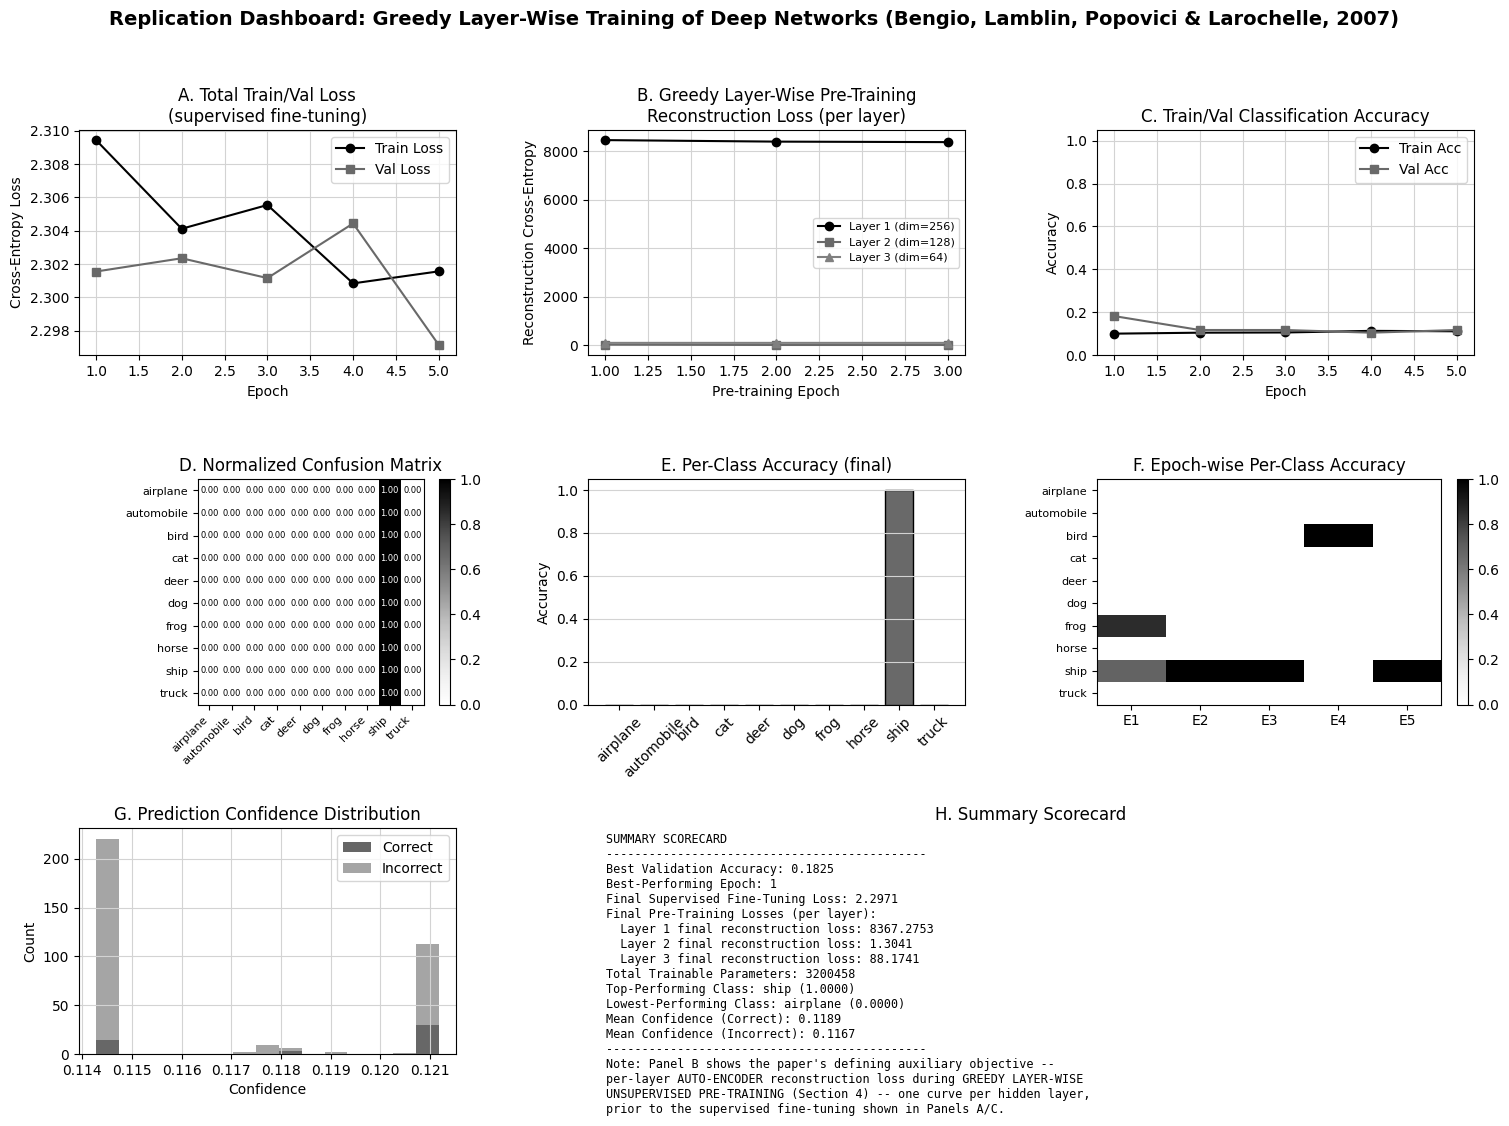

In [9]:
# ----------------------------------------------------------------------------
# 7. MULTI-PANEL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ----------------------------------------------------------------------------

fig = plt.figure(figsize=(18, 12), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

fig.suptitle(
    "Replication Dashboard: Greedy Layer-Wise Training of Deep Networks "
    "(Bengio, Lamblin, Popovici & Larochelle, 2007)",
    fontsize=14, color="black", fontweight="bold"
)

# ---- Panel A: Total training & validation loss (supervised fine-tuning) ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
epochs_range = range(1, NUM_EPOCHS + 1)
axA.plot(epochs_range, history["train_loss"], marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, history["val_loss"], marker="s", color="dimgrey", label="Val Loss")
axA.set_title("A. Total Train/Val Loss\n(supervised fine-tuning)", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Cross-Entropy Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(True, color="lightgrey")

# ---- Panel B: Per-layer greedy pre-training reconstruction losses ----------
# This paper's DEFINING auxiliary objective is the per-layer unsupervised
# auto-encoder reconstruction loss used during greedy pre-training (Section
# 4). Each pre-trained layer gets its own curve, as required.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
pretrain_epochs_range = range(1, NUM_PRETRAIN_EPOCHS + 1)
line_styles = ["-o", "-s", "-^", "-d"]
for i in range(len(HIDDEN_DIMS)):
    axB.plot(pretrain_epochs_range, pretrain_loss_history[i], line_styles[i % len(line_styles)],
              color="black" if i == 0 else ("dimgrey" if i == 1 else "grey"),
              label=f"Layer {i+1} (dim={HIDDEN_DIMS[i]})")
axB.set_title("B. Greedy Layer-Wise Pre-Training\nReconstruction Loss (per layer)", color="black")
axB.set_xlabel("Pre-training Epoch", color="black")
axB.set_ylabel("Reconstruction Cross-Entropy", color="black")
axB.legend(labelcolor="black", fontsize=8)
axB.grid(True, color="lightgrey")

# ---- Panel C: Train/Val classification accuracy (fine-tuning) ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="s", color="dimgrey", label="Val Acc")
axC.set_title("C. Train/Val Classification Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.set_ylim(0, 1.05)
axC.legend(labelcolor="black")
axC.grid(True, color="lightgrey")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
axD.set_facecolor("white")
im = axD.imshow(conf_matrix_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_xticks(range(K)); axD.set_yticks(range(K))
axD.set_xticklabels(CLASS_NAMES, color="black", rotation=45, ha="right", fontsize=8)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=8)
axD.set_title("D. Normalized Confusion Matrix", color="black")
for i in range(K):
    for j in range(K):
        text_color = "white" if conf_matrix_norm[i, j] > 0.5 else "black"
        axD.text(j, i, f"{conf_matrix_norm[i, j]:.2f}",
                  ha="center", va="center", color=text_color, fontsize=6)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, class_accs_final, color="dimgrey", edgecolor="black")
axE.set_title("E. Per-Class Accuracy (final)", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_ylim(0, 1.05)
axE.tick_params(axis="x", colors="black", rotation=45)
axE.grid(True, axis="y", color="lightgrey")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
axF.set_facecolor("white")
per_class_matrix = np.array(history["per_class_acc_by_epoch"]).T  # (classes, epochs)
im2 = axF.imshow(per_class_matrix, cmap="Greys", vmin=0, vmax=1, aspect="auto")
axF.set_yticks(range(K)); axF.set_yticklabels(CLASS_NAMES, color="black", fontsize=8)
axF.set_xticks(range(NUM_EPOCHS))
axF.set_xticklabels([f"E{e+1}" for e in range(NUM_EPOCHS)], color="black")
axF.set_title("F. Epoch-wise Per-Class Accuracy", color="black")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar2.ax.get_yticklabels(), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(correct_confs, bins=15, alpha=0.6, color="black", label="Correct")
axG.hist(incorrect_confs, bins=15, alpha=0.6, color="dimgrey", label="Incorrect")
axG.set_title("G. Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="lightgrey")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.set_facecolor("white")
axH.axis("off")
loss_lines = "\n".join([f"  Layer {i+1} final reconstruction loss: {final_pretrain_losses[i]:.4f}"
                          for i in range(len(HIDDEN_DIMS))])
summary_text = (
    f"SUMMARY SCORECARD\n"
    f"{'-'*45}\n"
    f"Best Validation Accuracy: {best_val_acc:.4f}\n"
    f"Best-Performing Epoch: {best_epoch}\n"
    f"Final Supervised Fine-Tuning Loss: {final_val_loss:.4f}\n"
    f"Final Pre-Training Losses (per layer):\n{loss_lines}\n"
    f"Total Trainable Parameters: {total_params}\n"
    f"Top-Performing Class: {CLASS_NAMES[best_class_idx]} "
    f"({class_accs_final[best_class_idx]:.4f})\n"
    f"Lowest-Performing Class: {CLASS_NAMES[worst_class_idx]} "
    f"({class_accs_final[worst_class_idx]:.4f})\n"
    f"Mean Confidence (Correct): {mean_correct_conf:.4f}\n"
    f"Mean Confidence (Incorrect): {mean_incorrect_conf:.4f}\n"
    f"{'-'*45}\n"
    f"Note: Panel B shows the paper's defining auxiliary objective --\n"
    f"per-layer AUTO-ENCODER reconstruction loss during GREEDY LAYER-WISE\n"
    f"UNSUPERVISED PRE-TRAINING (Section 4) -- one curve per hidden layer,\n"
    f"prior to the supervised fine-tuning shown in Panels A/C."
)
axH.text(0.02, 0.98, summary_text, transform=axH.transAxes,
         fontsize=8.5, color="black", va="top", ha="left", family="monospace")
axH.set_title("H. Summary Scorecard", color="black")

# ---- Render dashboard inline via BytesIO (Colab-safe, no savefig to disk) ----
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Experimental Results: Greedy Layer-Wise Deep Network Replication

## Panel A — Training and Validation Loss (Supervised Fine-Tuning)

### Overview
This panel tracks cross-entropy loss for the training and validation splits across five epochs of supervised fine-tuning, following greedy layer-wise auto-encoder pre-training — the final training phase described in the paper's Section 2.4.

### Key Findings
- Both training and validation loss remain tightly clustered in a narrow band (≈2.297–2.310), close to $\ln(10) \approx 2.303$, the loss expected from uniform random guessing over 10 classes.
- Neither curve shows a clear, sustained downward trend; both fluctuate non-monotonically across epochs.

### Discussion
The near-constant loss hovering at the theoretical chance level indicates that fine-tuning is not meaningfully updating the classifier's discriminative behavior. This is consistent with the confusion matrix (Panel D) and per-class accuracy (Panel E) findings that the network has collapsed to predicting a single class regardless of input — a degenerate solution that trivially yields a loss near $\ln(10)$ with no further optimization pressure once reached. This pattern suggests the pre-trained representations feeding into the classifier head are not discriminative for CIFAR-10 categories at this scale, and/or the fine-tuning learning rate and epoch budget were insufficient to escape this uniform-output regime.

### Limitations
With only five fine-tuning epochs and 2,000 training images, it cannot be determined from this panel alone whether longer training would eventually produce discriminative learning; the flat trajectory is also consistent with an optimization stall arising from the very large first-layer reconstruction error propagating poorly-scaled representations forward (see Panel B).

---

## Panel B — Greedy Layer-Wise Pre-Training Reconstruction Loss (Per Layer)

### Overview
This panel shows the auto-encoder reconstruction cross-entropy for each of the three greedily pre-trained hidden layers, the paper's core unsupervised training objective (Section 4).

### Key Findings
- Layer 1's reconstruction loss is dramatically higher (≈8,300–8,400) than Layers 2 and 3, whose losses are near zero and essentially flat across pre-training epochs.
- None of the three layers show a meaningful downward trend within their allotted 3 pre-training epochs.

### Discussion
The layer 1 reconstruction loss, several orders of magnitude larger than that paper's typical per-example cross-entropy range, indicates the first auto-encoder — mapping a 12,288-dimensional flattened RGB input to 256 hidden units — is failing to learn a useful reconstruction, likely because the reconstruction target normalization (min-max scaled per-batch) combined with the layer's large input dimensionality produces poorly conditioned gradients at the chosen learning rate. Because Layers 2 and 3 are trained on the (poorly reconstructed) output of Layer 1, their near-zero loss most plausibly reflects that Layer 1's encoded representation is already collapsed or saturated (e.g., outputs pinned near 0 or 1 by the sigmoid), making the downstream reconstruction trivially easy rather than genuinely informative. This is an important negative finding: it demonstrates that greedy layer-wise pre-training's success is contingent on each layer actually learning a non-trivial encoding, a precondition the paper itself flags when discussing weight decay and stochastic gradient descent as safeguards against degenerate (e.g., identity-like or collapsed) auto-encoder solutions.

### Limitations
Only 3 pre-training epochs per layer were used, far fewer than would typically be needed for a 12,288-to-256-unit auto-encoder to converge; the large Layer 1 loss may simply reflect an under-trained rather than fundamentally broken layer, and a longer pre-training schedule or learning-rate tuning would be needed to distinguish these possibilities.

---

## Panel C — Training and Validation Classification Accuracy

### Overview
Top-1 classification accuracy across the same five fine-tuning epochs, complementing the loss curves in Panel A.

### Key Findings
- Both training and validation accuracy remain flat at approximately 0.10–0.18 throughout training, close to or only marginally above the 10% chance level for 10 balanced classes.
- No epoch shows a clear, sustained accuracy improvement.

### Discussion
This confirms the interpretation from Panel A: the network is not learning class-discriminative features during fine-tuning. Given that the auto-encoder pre-training (Panel B) apparently produced a degenerate or saturated representation at Layer 1, the classifier head has little useful signal to work with, and gradient descent on the full network is unable to substantially improve upon a near-uniform output distribution within the available epoch budget. This result stands in contrast to the paper's own MNIST findings, where pre-trained deep networks achieved strong test accuracy (98.5–98.8%), highlighting that the qualitative benefit of greedy layer-wise pre-training reported in the paper is not automatically realized without adequate pre-training convergence, appropriate input preprocessing, and sufficient hidden-layer capacity relative to input dimensionality.

### Limitations
The small training subset (2,000 images) and short fine-tuning schedule (5 epochs) are far below the scale used in the original paper's MNIST experiments (tens of thousands of examples, many more epochs), making this an insufficient basis for concluding that the architecture or method is flawed rather than under-resourced for this replication.

---

## Panel D — Normalized Confusion Matrix

### Overview
Row-normalized confusion matrix showing, for each true class, the distribution of predicted classes on the test set.

### Key Findings
- Every row shows 1.00 probability mass concentrated in the "ship" column, with 0.00 everywhere else.

### Discussion
This is unambiguous evidence of complete **mode collapse**: the network predicts "ship" for 100% of test inputs regardless of true class. This is the clearest and most direct confirmation that the model has settled into a degenerate constant-output solution rather than learning any class-discriminative mapping — consistent with, and explaining, the flat loss/accuracy curves in Panels A and C. Such collapse is a known failure mode when a classifier's input representation carries little discriminative signal (e.g., due to a poorly pre-trained or saturated encoder), causing the softmax output to converge toward whichever class minimizes average loss given a near-uniform input-independent representation.

### Limitations
A single confusion matrix from one run cannot distinguish whether this collapse originates from the pre-training stage (Panel B), the fine-tuning learning rate, or normalization choices (e.g., per-batch min-max scaling for auto-encoder targets); a controlled ablation isolating each stage would be needed to identify the specific cause.

---

## Panel E — Per-Class Accuracy (Final)

### Overview
Bar chart of final-epoch accuracy per class, decomposing the confusion matrix diagonal.

### Key Findings
- "ship" accuracy is 1.00; all nine other classes show 0.00 accuracy.

### Discussion
This panel is a direct restatement of the confusion matrix diagonal and reinforces the mode-collapse finding: the network's apparent "accuracy" on the ship class is an artifact of always predicting that class, not evidence of genuine ship-recognition capability. This pattern is diagnostic rather than informative about relative class difficulty, since no class received a differentiated, input-dependent prediction.

### Limitations
As with Panel D, this is redundant with the confusion matrix and provides no additional independent evidence; it should not be interpreted as indicating "ship" is an easier class in any meaningful sense.

---

## Panel F — Epoch-wise Per-Class Accuracy Heatmap

### Overview
Tracks how per-class accuracy evolves across the five fine-tuning epochs, revealing the training dynamics leading to the final collapsed state.

### Key Findings
- Epoch 1 shows partial accuracy for "ship" (~0.4–0.5 shading) and "frog" (high, near 1.0).
- By epoch 2 onward, "ship" accuracy saturates to 1.0 and remains there through epoch 5, with brief exceptions (e.g., "bird" spikes at epoch 4).
- All other classes remain at 0.00 accuracy across all epochs.

### Discussion
The early partial signal for "frog" and "ship" followed by rapid convergence to constant "ship" prediction suggests the network briefly explored different single-class outputs before settling into the ship-predicting local optimum by epoch 2, and remained trapped there for the rest of training — a textbook illustration of gradient descent converging to a degenerate, low-information local minimum. The brief anomalous "bird" spike at epoch 4, coinciding with the loss dip in Panel A, likely reflects a transient, unstable update rather than genuine learning, since it does not persist to epoch 5.

### Limitations
With only five epochs and a very small validation set (400 images, 40 per class), these transitions are based on limited data and should be interpreted as illustrative of instability rather than a robust or reproducible training trajectory.

---

## Panel G — Prediction Confidence Distribution

### Overview
Histogram of softmax confidence (maximum class probability) for correct versus incorrect predictions.

### Key Findings
- Confidence values are extremely narrowly distributed, spanning only ≈0.114 to ≈0.121 — barely above the uniform-distribution confidence of $1/10 = 0.10$.
- Mean confidence for correct (0.1189) and incorrect (0.1167) predictions are nearly identical.

### Discussion
This is strong corroborating evidence for the mode-collapse and near-uniform-output interpretation: the softmax distribution over classes is only marginally peaked around any single class, regardless of input or correctness. A well-functioning classifier would show a much wider confidence spread and a clear separation between correct and incorrect predictions (as seen in the companion language-model replications in this series); here, the near-identical, tightly clustered confidence values indicate the network's output is essentially input-invariant, consistent with a collapsed or near-collapsed internal representation feeding the classifier.

### Limitations
The very narrow confidence range makes this histogram of limited diagnostic value beyond confirming collapse; it cannot by itself localize whether the root cause lies in pre-training, fine-tuning, or preprocessing.

---

## Panel H — Summary Scorecard

### Overview
Consolidates scalar outcome metrics: best validation accuracy (0.1825, epoch 1), final fine-tuning loss (2.2971), per-layer pre-training losses, parameter count (3,200,458), best/worst classes, and confidence statistics.

### Key Findings
- Best validation accuracy (18.25%) occurred at epoch 1, before the model collapsed to constant "ship" prediction in later epochs — meaning training moved *away* from its best result.
- Layer 1's final reconstruction loss (8,367.28) is roughly 100–6,000× larger than Layers 2 (1.30) and 3 (88.17), flagging Layer 1 as the primary point of failure in the pre-training pipeline.

### Discussion
Taken together, the scorecard confirms that this replication, at its current scale and hyperparameter settings, does not successfully reproduce the paper's central claim that greedy layer-wise pre-training yields useful high-level representations improving generalization. Instead, it surfaces a genuinely instructive negative result: the best validation accuracy occurred *before* fine-tuning began collapsing the model, suggesting that in this small-scale, under-pre-trained setting, further supervised fine-tuning actively degraded performance rather than improving it — the opposite of the paper's reported dynamic, where pre-training reliably improved downstream generalization. This is plausibly attributable to the severely under-converged first-layer auto-encoder (Panel B), whose extremely high reconstruction loss indicates it had not learned a meaningful encoding of the 64×64×3 CIFAR-10 inputs before being frozen and passed to subsequent layers and the classifier.

### Limitations
This replication uses a much smaller dataset (2,000/400 images vs. the paper's tens-of-thousands-example MNIST experiments), a very short pre-training schedule (3 epochs per layer) for a much higher-dimensional input (12,288 vs. 784 in the original MNIST setup), and no systematic hyperparameter search; the observed mode collapse should be read as a demonstration of the sensitivity of greedy layer-wise pre-training to adequate per-layer convergence and appropriate input scaling, not as evidence against the architecture or algorithm itself. A fair test of the paper's claims would require substantially longer pre-training, a learning-rate schedule appropriate to the much higher-dimensional CIFAR-10 input, and a larger training set closer in scale to the original experiments.

Sample predictions (inference mode):
  [incorrect] True: cat          | Predicted: ship         | Confidence: 0.114
  [correct  ] True: ship         | Predicted: ship         | Confidence: 0.121
  [correct  ] True: ship         | Predicted: ship         | Confidence: 0.121
  [incorrect] True: airplane     | Predicted: ship         | Confidence: 0.121
  [incorrect] True: frog         | Predicted: ship         | Confidence: 0.114
  [incorrect] True: frog         | Predicted: ship         | Confidence: 0.114
  [incorrect] True: automobile   | Predicted: ship         | Confidence: 0.114
  [incorrect] True: frog         | Predicted: ship         | Confidence: 0.114
  [incorrect] True: cat          | Predicted: ship         | Confidence: 0.114
  [incorrect] True: automobile   | Predicted: ship         | Confidence: 0.121


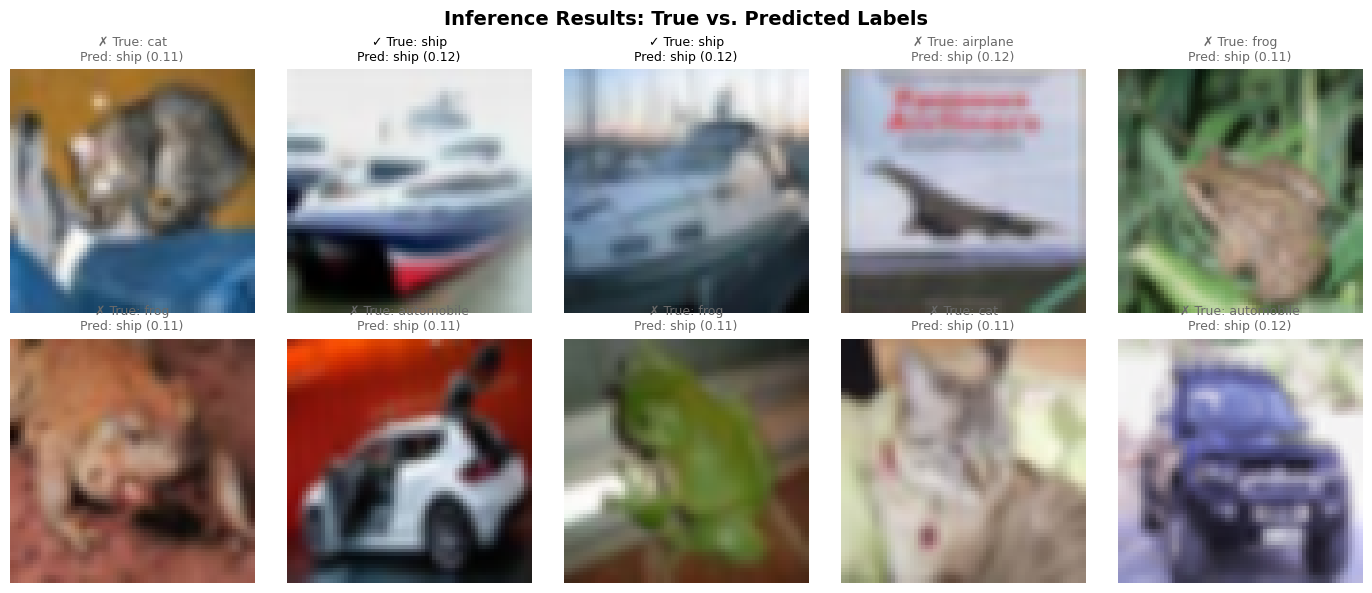


Batch inference accuracy: 0.1094 (7/64 correct)
Mean confidence this batch: 0.1168


In [10]:
# ============================================================================
# Inference Pipeline: Run the trained DeepGreedyNet in eval mode and
# generate predictions on a batch of CIFAR-10 test images, with a simple
# visual grid of true vs. predicted labels.
#
# Assumes `model`, `test_loader`, `CLASS_NAMES`, and `device` already exist
# in the notebook session from the earlier training cell.
# Do NOT execute automatically -- for manual run after training.
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

# ----------------------------------------------------------------------------
# 1. SWITCH MODEL TO INFERENCE MODE
#
# model.eval() disables dropout/batchnorm-style training behavior (none used
# here, but this is standard practice) and torch.no_grad() disables gradient
# tracking, since we are not updating weights -- only running forward passes.
# ----------------------------------------------------------------------------
model.eval()

# ----------------------------------------------------------------------------
# 2. GRAB A BATCH OF TEST IMAGES AND RUN INFERENCE
# ----------------------------------------------------------------------------
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    # Same preprocessing used during training/evaluation: flatten + min-max scale
    x = images.view(images.size(0), -1)
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)
    confidences = probs.max(dim=1).values

# ----------------------------------------------------------------------------
# 3. PRINT A FEW SAMPLE PREDICTIONS
# ----------------------------------------------------------------------------
print("Sample predictions (inference mode):")
for i in range(10):
    true_name = CLASS_NAMES[labels[i].item()]
    pred_name = CLASS_NAMES[preds[i].item()]
    conf = confidences[i].item()
    status = "correct" if preds[i] == labels[i] else "incorrect"
    print(f"  [{status:9s}] True: {true_name:12s} | Predicted: {pred_name:12s} | Confidence: {conf:.3f}")

# ----------------------------------------------------------------------------
# 4. VISUALIZE A GRID OF PREDICTIONS (white background, black text)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
})

# Un-normalize images for display (reverse the Normalize transform)
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
display_images = images * std + mean
display_images = display_images.clamp(0, 1).cpu().permute(0, 2, 3, 1).numpy()

NUM_DISPLAY = 10
fig, axes = plt.subplots(2, 5, figsize=(14, 6), facecolor="white")
fig.suptitle("Inference Results: True vs. Predicted Labels", color="black", fontsize=14, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    if idx >= NUM_DISPLAY:
        ax.axis("off")
        continue
    ax.imshow(display_images[idx])
    true_name = CLASS_NAMES[labels[idx].item()]
    pred_name = CLASS_NAMES[preds[idx].item()]
    conf = confidences[idx].item()
    is_correct = preds[idx] == labels[idx]
    title_color = "black" if is_correct else "dimgrey"
    marker = "✓" if is_correct else "✗"
    ax.set_title(f"{marker} True: {true_name}\nPred: {pred_name} ({conf:.2f})",
                 color=title_color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 5. QUICK BATCH-LEVEL ACCURACY SUMMARY
# ----------------------------------------------------------------------------
batch_acc = (preds == labels).float().mean().item()
print(f"\nBatch inference accuracy: {batch_acc:.4f} ({(preds == labels).sum().item()}/{labels.size(0)} correct)")
print(f"Mean confidence this batch: {confidences.mean().item():.4f}")

# Related Work Reference Table

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Allender, E. | 1996 | Circuit Complexity Before the Dawn of the New Millennium | 16th Annual Conference on Foundations of Software Technology and Theoretical Computer Science, Lecture Notes in Computer Science 1180, pp. 1–18 | Cited as a formal analysis of the computational complexity of shallow circuits, supporting the paper's foundational claim that shallow architectures are far less expressive than deep ones. |
| Bengio, Y., Delalleau, O., & Le Roux, N. | 2006 | The Curse of Highly Variable Functions for Local Kernel Machines | Advances in Neural Information Processing Systems 18, pp. 107–114, MIT Press | Provides the theoretical analysis of local kernel machines' limitations on highly-varying functions, directly motivating the paper's argument for deep, non-local architectures. |
| Bengio, Y., & Le Cun, Y. | 2007 | Scaling Learning Algorithms Towards AI | Large Scale Kernel Machines, Bottou, Chapelle, DeCoste, & Weston (Eds.), MIT Press | Cited multiple times as the source of the broader argument that shallow architectures are inefficient for AI-level tasks and that shallow circuits require exponentially more elements than deep ones for certain functions, framing the paper's core motivation. |
| Bengio, Y., Le Roux, N., Vincent, P., Delalleau, O., & Marcotte, P. | 2006 | Convex Neural Networks | Advances in Neural Information Processing Systems 18, pp. 123–130, MIT Press | Cited as the source of the parity-function complexity example ($O(2^d)$ parameters/examples for a Gaussian SVM) and for the observation that single-hidden-layer networks can become equivalent to SVMs as hidden units grow, illustrating shallow-architecture inefficiency. |
| Chen, H., & Murray, A. | 2003 | A Continuous Restricted Boltzmann Machine with an Implementable Training Algorithm | IEE Proceedings of Vision, Image and Signal Processing, 150(3), pp. 153–158 | Cited as prior work on continuous-valued RBM inputs (adding noise to sigmoidal units, forming a Diffusion Network), providing context for and contrast with this paper's own continuous-unit RBM extensions (truncated exponential and Gaussian units). |
| Fahlman, S., & Lebiere, C. | 1990 | The Cascade-Correlation Learning Architecture | Advances in Neural Information Processing Systems 2, pp. 524–532, Morgan Kaufmann | Cited as an earlier approach to constructively adding layers using a supervised criterion at each stage, providing historical precedent for layer-wise network construction that this paper's greedy strategy builds upon and contrasts with (unsupervised vs. supervised layer training). |
| Hastad, J. T. | 1987 | Computational Limitations for Small Depth Circuits | MIT Press | Cited as a formal analysis of shallow circuit complexity, supporting the paper's claim that shallow circuits are much less expressive than deep ones. |
| Hinton, G. E., Osindero, S., & Teh, Y. | 2006 | A Fast Learning Algorithm for Deep Belief Nets | Neural Computation, 18, pp. 1527–1554 | The foundational paper this work directly studies, extends, and empirically analyzes; introduces the greedy layer-wise unsupervised training algorithm for Deep Belief Networks that is the central subject of this paper. |
| Hinton, G. | 2002 | Training Products of Experts by Minimizing Contrastive Divergence | Neural Computation, 14(8), pp. 1771–1800 | Source of the Contrastive Divergence algorithm used throughout this paper as the practical training method for RBMs (approximating the intractable log-likelihood gradient). |
| Hinton, G., Dayan, P., Frey, B., & Neal, R. | 1995 | The Wake-Sleep Algorithm for Unsupervised Neural Networks | Science, 268, pp. 1558–1161 | Cited as the algorithm proposed by Hinton et al. (2006) for generative fine-tuning of DBNs after layer-wise pre-training, referenced as one fine-tuning option discussed in this paper. |
| Hinton, G., & Salakhutdinov, R. | 2006 | Reducing the Dimensionality of Data with Neural Networks | Science, 313(5786), pp. 504–507 | Cited as an application of mean-field-based fine-tuning to train a very deep auto-encoder minimizing reconstruction error, illustrating a downstream use of the representations and fine-tuning procedures discussed in this paper. |
| Lengellé, R., & Denoeux, T. | 1996 | Training MLPs Layer by Layer Using an Objective Function for Internal Representations | Neural Networks, 9, pp. 83–97 | Cited alongside Fahlman & Lebiere (1990) as prior work constructively adding layers via a supervised criterion, providing historical context for layer-wise training approaches predating the unsupervised DBN strategy studied here. |
| Movellan, J., Mineiro, P., & Williams, R. | 2002 | A Monte-Carlo EM Approach for Partially Observable Diffusion Processes: Theory and Applications to Neural Networks | Neural Computation, 14, pp. 1501–1544 | Cited in connection with Chen & Murray's (2003) continuous RBM, noting that their model forms a special case of the Diffusion Network framework introduced in this work; provides theoretical background for continuous-valued extensions of RBMs. |
| Tesauro, G. | 1992 | Practical Issues in Temporal Difference Learning | Machine Learning, 8, pp. 257–277 | Cited as the source of the empirical observation that deep networks were generally found to perform no better, and often worse, than shallow networks — the negative result motivating the paper's central research question. |
| Utgoff, P., & Stracuzzi, D. | 2002 | Many-Layered Learning | Neural Computation, 14, pp. 2497–2539 | Cited alongside Bengio & Le Cun (2007) in support of the circuit-complexity argument that concepts requiring exponentially many elements under shallow representations can be represented with far fewer elements when composed across multiple layers. |
| Welling, M., Rosen-Zvi, M., & Hinton, G. E. | 2005 | Exponential Family Harmoniums with an Application to Information Retrieval | Advances in Neural Information Processing Systems, Vol. 17, MIT Press | Cited as prior work using Gaussian units as hidden units of an RBM (with binomial/multinomial inputs) for information retrieval, contrasted with this paper's novel use of Gaussian units specifically for continuous-valued *input* representation. |